Extracting the learning set and test set from the .txt file that generated during eucildean distance

In [1]:
seed_value = 0
h_neurons = 16
l_rate = 0.001

In [2]:

def extract_L_set(filepath):
    l_set = []
    capture = False
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
        
            # Start capturing when we see the header
            if line.startswith("L set:"):
                capture = True
                continue
        
            # Stop capturing when we reach the B vector
            if line.startswith("B vector:"):
                capture = False
                break
            
            # If we are in the capture zone and the line looks like a list
            if capture and line.startswith("["):
                # ast.literal_eval safely converts the string "[1, 2...]" into a Python list
                row = ast.literal_eval(line)
                l_set.append(row)
    return l_set

Remember not to change the seed value, it is really important to get the exact result everytime, without changing the model's parameters. Without seed, every run gives different result thought the parameters are same. 

In [3]:
import numpy as np
import ast #abstract syntax tree module for safe evaluation of string.
import random
loaded_train_test_data = []
#first we loading the L set from 2003 to 2023
filePath = '../ED_Calculation/2003_2023/results/finalize_L_set_from_2003_to_2023.txt'
loaded_learning_data = np.array(extract_L_set(filePath))
random.seed(seed_value)
np.random.seed(seed_value)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#separate the training_validation for Feature and Target
X = loaded_learning_data[:, :5] #first five col of the row is feature
y = loaded_learning_data[:, 5] # 6th value is the target

#split for train and val
X_train = X[30:]
X_val = X[:30]
y_train = y[30:]
y_val = y[:30]

scaler =  StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print(f"Shape of X_train {X_train.shape}")
print(f"Shape of y_train{y_train.shape}")
print(f"Shape of X_val{X_val.shape}")
print(f"Shape of y_val{y_val.shape}")

Shape of X_train (115, 5)
Shape of y_train(115,)
Shape of X_val(30, 5)
Shape of y_val(30,)


It is time to define the test data from **2024 to 2025**.

In [5]:
loaded_test_data = []
test_filepath = "../ED_Calculation/2024_current/results/final_result_df_2024_2025.txt"
loaded_test_data = np.array(extract_L_set(test_filepath))
X_test = loaded_test_data[:, :5]
y_test = loaded_test_data[:, 5]

X_test = scaler.transform(X_test)


Now we are going to make a Feed Forward Neural Network, which has input layer with 5 feature, a hidden layer with initial neuron size 10 with signmoid function, and a signle neuron output layer with linear function.

In [6]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
tf.random.set_seed(seed_value)

# ffnn's parameters
epoch_size = 30
b_size = 8

#Create a model
ffnn = Sequential()
# Input layer (5 features)
ffnn.add(Input(shape=(X_train.shape[1],)))

ffnn.add(Dense(units=h_neurons, activation="relu",))
ffnn.add(Dense(units=1, activation="linear"))
ffnn.summary()


I0000 00:00:1778926369.800226   10331 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778926370.338042   10331 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778926372.437139   10331 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1778926373.341353   10331 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

Now compile and run the model

ModelCheckpoint is a callback function to help to save the model's configuration during every epoch.

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

class PrintValAccuracyOnly(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # Fetch the validation accuracy from the logs
        val_acc = logs.get('val_direction_accuracy')
        if val_acc is not None:
            print(f"Epoch {epoch + 1}: val_direction_accuracy: {val_acc:.4f}%")

def direction_accuracy(y_true, y_pred):
    true_sign = tf.sign(y_true)
    pred_sign = tf.sign(y_pred)
    matches = tf.equal(true_sign, pred_sign)
    return tf.reduce_mean(tf.cast(matches, tf.float32)) * 100
    


early_stopping = EarlyStopping(
    monitor='val_direction_accuracy', 
    mode='max',                       
    patience=5,                       
    restore_best_weights=True         
)


checkpoint = ModelCheckpoint(
    filepath=f'models/best_model.keras',
    monitor='val_direction_accuracy',
    save_weights_only= False,
    mode='max',
    save_best_only=True,              # Only save when the accuracy improves
    verbose=0
)


ffnn.compile(
    optimizer=Adam(learning_rate=l_rate), 
    loss='mse', 
    metrics=[direction_accuracy]      # Track this during training
)


print("Starting training... and evaluating validation")
ffnn_history = ffnn.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val),   # Calculate validation metrics per epoch
    epochs=epoch_size, 
    batch_size=b_size,
    callbacks=[early_stopping, checkpoint, PrintValAccuracyOnly()],
    verbose=0
)

Starting training... and evaluating validation
Epoch 1: val_direction_accuracy: 52.7778%
Epoch 2: val_direction_accuracy: 50.4340%
Epoch 3: val_direction_accuracy: 50.4340%
Epoch 4: val_direction_accuracy: 50.4340%
Epoch 5: val_direction_accuracy: 50.4340%
Epoch 6: val_direction_accuracy: 45.7465%


After trained the model, we are going to check and evaluate these  configs based on the validation set, using "correct directional percentage change". 
The best model configuratoion will be saved which gives biggest correct directional percentage change on the validation data set.

In here, we are going to select that best model, and evaluate the **prediction** against validation set.

In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf

best_model_path = f'models/best_model.keras'

best_model = tf.keras.models.load_model(best_model_path, compile=False)


y_val_pred = best_model.predict(X_val)

y_val_actual = np.ravel(y_val)
y_val_pred_flat = np.ravel(y_val_pred)

val_direction_match = (np.sign(y_val_actual) == np.sign(y_val_pred_flat)).astype(int)

val_results_df = pd.DataFrame({
    'Actual': y_val_actual,
    'Predicted': y_val_pred_flat,
    'Direction': val_direction_match
})

val_neg_match = ((val_results_df['Actual'] < 0) & (val_results_df['Predicted'] < 0)).sum()

# Count where actual > 0 AND predicted > 0  (positive match)
val_pos_match = ((val_results_df['Actual'] > 0) & (val_results_df['Predicted'] > 0)).sum()

print(f"--- Predictions for Best Model (from {best_model_path}) ---")
print(val_results_df)

final_val_acc = val_results_df['Direction'].mean() * 100
print(f"\nValidation Prediction Accuracy: {final_val_acc:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
--- Predictions for Best Model (from models/best_model.keras) ---
      Actual  Predicted  Direction
0   0.449403   0.351561          1
1  -1.033273   1.157060          0
2  -1.028040  -0.752068          1
3  -1.118594  -0.554849          1
4   0.304173  -2.450208          0
5   0.237958   1.108114          1
6  -0.179998   0.494825          0
7  -1.305160  -1.196067          1
8   1.118788  -0.091495          0
9  -0.404159   0.384436          0
10  0.274649  -0.283318          0
11  0.105960   0.601114          1
12  0.726266   0.482404          1
13 -0.662117   0.178508          0
14 -0.114420  -1.090519          1
15 -0.238144  -0.047869          1
16 -0.521055   0.383551          0
17  0.064410   0.304336          1
18 -0.177229  -0.187675          1
19 -0.075720  -0.390064          1
20 -0.691956   1.494031          0
21 -0.058821   0.764790          0
22 -0.192841  -0.314657          1
23 -0.885929  -0.071195          1
24  0.297621  -1.2718

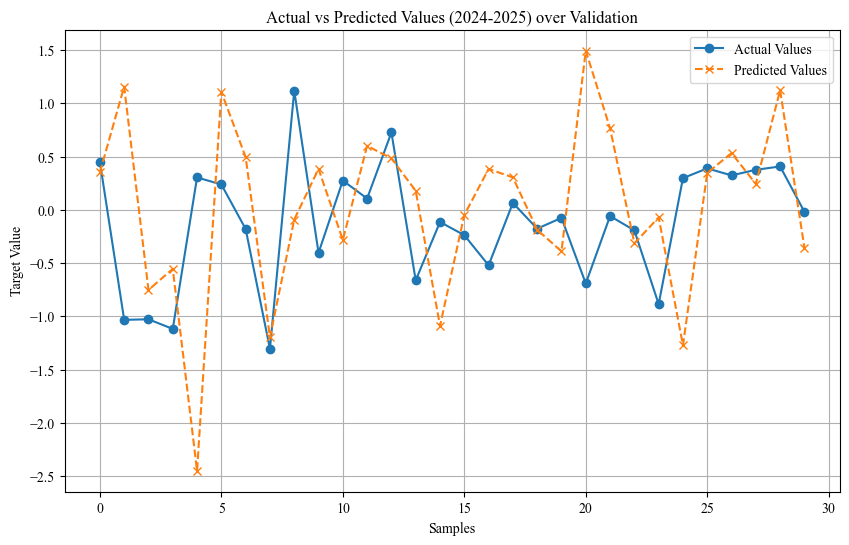

In [9]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_val_actual)), y_val_actual, label="Actual Values", marker="o")
plt.plot(range(len(y_val_pred_flat)), y_val_pred_flat, label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values (2024-2025) over Validation")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()

Again, load that best model for final evaluation with the test set.

In [10]:
# Load the best model
final_model = tf.keras.models.load_model(
    best_model_path, 
    custom_objects={'direction_accuracy': direction_accuracy},
    compile=False
)
final_model.compile(
    optimizer='adam',
    loss='mse', 
    metrics=[direction_accuracy]
)


test_results = final_model.evaluate(X_test, y_test, verbose=1)

print("-" * 30)
print(f"FINAL TEST SET PERFORMANCE")
print(f"Direction Accuracy: {test_results[1]:.2f}%")
print("-" * 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - direction_accuracy: 51.2397 - loss: 0.4102
------------------------------
FINAL TEST SET PERFORMANCE
Direction Accuracy: 51.24%
------------------------------


Get the prediction against test set.

In [11]:

ffnn_pred = final_model.predict(X_test)


y_test_flat = np.ravel(y_test)
ffnn_pred_flat = np.ravel(ffnn_pred)


direction_match = (np.sign(y_test_flat) == np.sign(ffnn_pred_flat)).astype(int)

import pandas as pd

results_df = pd.DataFrame({
    'Actual': y_test_flat,
    'Predicted': ffnn_pred_flat,
    'Direction': direction_match
})
test_neg_match = ((results_df['Actual'] < 0) & (results_df['Predicted'] < 0)).sum()

# Count where actual > 0 AND predicted > 0  (positive match)
test_pos_match = ((results_df['Actual'] > 0) & (results_df['Predicted'] > 0)).sum()

print(results_df)
ffnn_test_acc = results_df['Direction'].mean() * 100
print(f"\nTest Prediction Accuracy: {ffnn_test_acc:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
      Actual  Predicted  Direction
0  -0.017473  -0.017740          1
1  -0.339443  -0.813929          1
2   0.031541   0.100092          1
3  -0.215161   0.954324          0
4  -0.087107  -0.003860          1
5   0.485383   0.676263          1
6  -0.220254   1.097035          0
7   0.307394   0.163671          1
8   0.306878   0.489501          1
9   0.113420   0.805058          1
10  0.198257  -0.578539          0

Test Prediction Accuracy: 72.73%


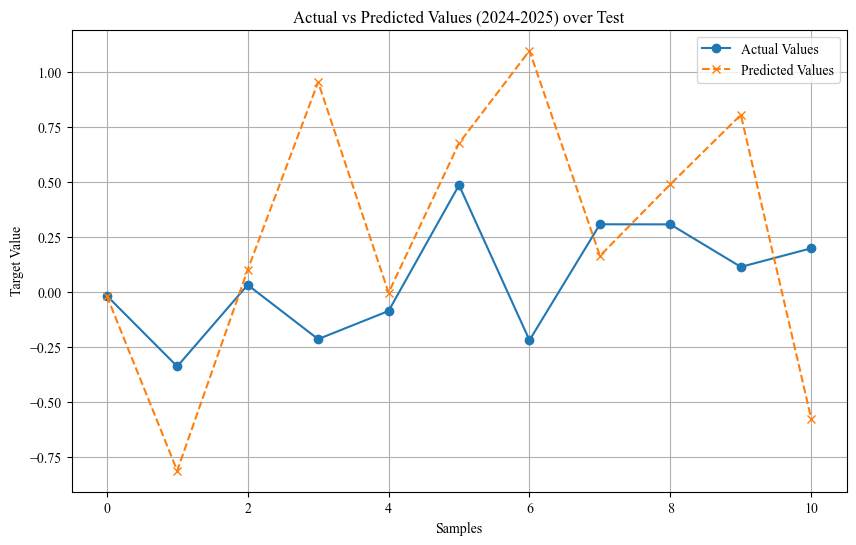

In [12]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test_flat)), y_test_flat, label="Actual Values", marker="o")
plt.plot(range(len(ffnn_pred_flat)), ffnn_pred_flat, label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values (2024-2025) over Test")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()

This part wil be our knn

In [13]:
from sklearn.neighbors import KNeighborsRegressor
# --- PART A: KNN IMPLEMENTATION ---
print("--- Optimizing KNN ---")
best_k = 1
best_knn_val_acc = 0

# Test different K values on the 30 validation samples
for k in range(1, 21, 1):
    knn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    val_preds = knn.predict(X_val)
    acc = direction_accuracy(y_val, val_preds)
    
    if acc > best_knn_val_acc:
        best_knn_val_acc = acc
        best_k = k
    print(f"KNN K: {k} Val Acc: {acc:.2f}%")

print(f"Best KNN K: {best_k} (Val Acc: {best_knn_val_acc:.2f}%)")

--- Optimizing KNN ---
KNN K: 1 Val Acc: 46.67%
KNN K: 2 Val Acc: 40.00%
KNN K: 3 Val Acc: 33.33%
KNN K: 4 Val Acc: 36.67%
KNN K: 5 Val Acc: 33.33%
KNN K: 6 Val Acc: 36.67%
KNN K: 7 Val Acc: 40.00%
KNN K: 8 Val Acc: 30.00%
KNN K: 9 Val Acc: 33.33%
KNN K: 10 Val Acc: 23.33%
KNN K: 11 Val Acc: 30.00%
KNN K: 12 Val Acc: 30.00%
KNN K: 13 Val Acc: 33.33%
KNN K: 14 Val Acc: 26.67%
KNN K: 15 Val Acc: 30.00%
KNN K: 16 Val Acc: 30.00%
KNN K: 17 Val Acc: 33.33%
KNN K: 18 Val Acc: 36.67%
KNN K: 19 Val Acc: 36.67%
KNN K: 20 Val Acc: 36.67%
Best KNN K: 1 (Val Acc: 46.67%)


In [14]:
# Final KNN Model
final_knn = KNeighborsRegressor(n_neighbors=2, metric='euclidean', weights='uniform')
final_knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
#final_knn.evaluate(X_test, y_test, verbose=1)
knn_pred = final_knn.predict(X_test)
knn_direction_match = (np.sign(y_test_flat) == np.sign(knn_pred)).astype(int)

import pandas as pd

knn_results = pd.DataFrame({
    'Actual': y_test_flat,
    'Predicted': knn_pred,
    'Direction': knn_direction_match
})
test_neg_match = ((knn_results['Actual'] < 0) & (knn_results['Predicted'] < 0)).sum()

# Count where actual > 0 AND predicted > 0  (positive match)
test_pos_match = ((knn_results['Actual'] > 0) & (knn_results['Predicted'] > 0)).sum()

print(knn_results)
final_knn_test_acc = knn_results['Direction'].mean() * 100
print(f"\nTest Prediction Accuracy: {final_knn_test_acc:.2f}%")

      Actual  Predicted  Direction
0  -0.017473  -0.391660          1
1  -0.339443   0.291160          0
2   0.031541   0.043536          1
3  -0.215161   0.150028          0
4  -0.087107   0.352391          0
5   0.485383  -0.162532          0
6  -0.220254   0.861398          0
7   0.307394   0.446497          1
8   0.306878   0.066970          1
9   0.113420   0.790992          1
10  0.198257   0.104902          1

Test Prediction Accuracy: 54.55%


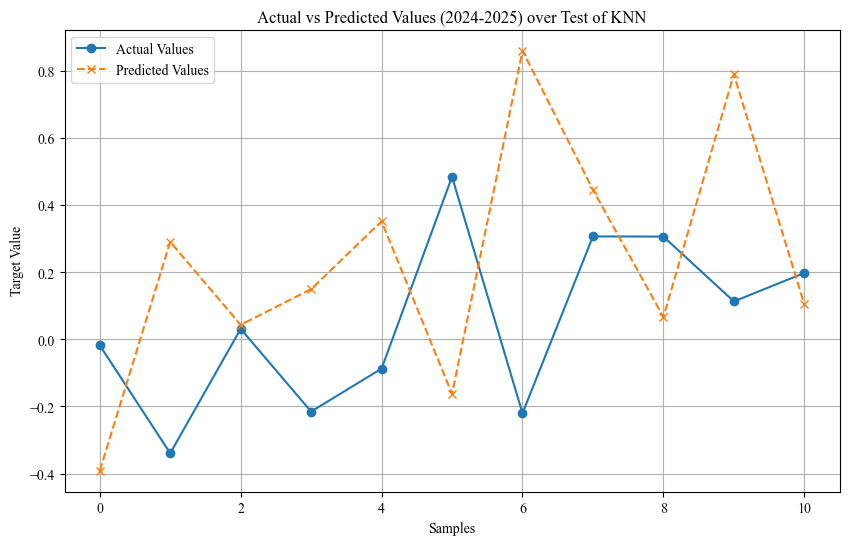

In [16]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test_flat)), y_test_flat, label="Actual Values", marker="o")
plt.plot(range(len(knn_pred)), knn_pred, label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values (2024-2025) over Test of KNN")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Ensemble: Average the predictions
ensemble_preds = (knn_pred + ffnn_pred_flat) / 2
ensemble_acc = direction_accuracy(y_test_flat, ensemble_preds)

# Consensus: Only trade if they agree
matches = 0
total_agreements = 0
for i in range(len(y_test_flat)):
    k_dir = 1 if knn_pred[i] >= 0 else -1
    f_dir = 1 if ffnn_pred_flat[i] >= 0 else -1
    actual = 1 if y_test_flat[i] >= 0 else -1
    
    
    if k_dir == f_dir:
        total_agreements += 1
        if k_dir == actual:
            matches += 1
    print(f"{i:2d}. knn: {k_dir:2d} __ ffnn: {f_dir:2d} __ Actual: {actual:2d} __ Both Agree: {k_dir == f_dir:2d} __ Match: {k_dir == actual:2d} ")

consensus_acc = (matches / total_agreements * 100) if total_agreements > 0 else 0

print(f"KNN Test Accuracy: {final_knn_test_acc:.2f}%")
print(f"FFNN Test Accuracy: {ffnn_test_acc:.2f}%")
print(f"Ensemble (Mean) Accuracy: {ensemble_acc:.2f}%")
print(f"Consensus Accuracy (When they agree): {consensus_acc:.2f}%")
print(f"Confidence Rate: {total_agreements}/{len(y_test)} samples")

 0. knn: -1 __ ffnn: -1 __ Actual: -1 __ Both Agree:  1 __ Match:  1 
 1. knn:  1 __ ffnn: -1 __ Actual: -1 __ Both Agree:  0 __ Match:  0 
 2. knn:  1 __ ffnn:  1 __ Actual:  1 __ Both Agree:  1 __ Match:  1 
 3. knn:  1 __ ffnn:  1 __ Actual: -1 __ Both Agree:  1 __ Match:  0 
 4. knn:  1 __ ffnn: -1 __ Actual: -1 __ Both Agree:  0 __ Match:  0 
 5. knn: -1 __ ffnn:  1 __ Actual:  1 __ Both Agree:  0 __ Match:  0 
 6. knn:  1 __ ffnn:  1 __ Actual: -1 __ Both Agree:  1 __ Match:  0 
 7. knn:  1 __ ffnn:  1 __ Actual:  1 __ Both Agree:  1 __ Match:  1 
 8. knn:  1 __ ffnn:  1 __ Actual:  1 __ Both Agree:  1 __ Match:  1 
 9. knn:  1 __ ffnn:  1 __ Actual:  1 __ Both Agree:  1 __ Match:  1 
10. knn:  1 __ ffnn: -1 __ Actual:  1 __ Both Agree:  0 __ Match:  1 
KNN Test Accuracy: 54.55%
FFNN Test Accuracy: 72.73%
Ensemble (Mean) Accuracy: 63.64%
Consensus Accuracy (When they agree): 71.43%
Confidence Rate: 7/11 samples


In [18]:

direction_knn = (np.sign(y_test_flat) == np.sign(knn_pred)).astype(int)
direction_ffnn = (np.sign(y_test_flat) == np.sign(ffnn_pred_flat)).astype(int)
knn_ffnn_results = pd.DataFrame({
    'Actual': y_test_flat,
    'knn': knn_pred,
    'ffnn': ffnn_pred_flat,
    'Direction': [f"K: {k} | F: {f}" for k, f in zip(direction_knn, direction_ffnn)]
})

print(knn_ffnn_results)

      Actual       knn      ffnn    Direction
0  -0.017473 -0.391660 -0.017740  K: 1 | F: 1
1  -0.339443  0.291160 -0.813929  K: 0 | F: 1
2   0.031541  0.043536  0.100092  K: 1 | F: 1
3  -0.215161  0.150028  0.954324  K: 0 | F: 0
4  -0.087107  0.352391 -0.003860  K: 0 | F: 1
5   0.485383 -0.162532  0.676263  K: 0 | F: 1
6  -0.220254  0.861398  1.097035  K: 0 | F: 0
7   0.307394  0.446497  0.163671  K: 1 | F: 1
8   0.306878  0.066970  0.489501  K: 1 | F: 1
9   0.113420  0.790992  0.805058  K: 1 | F: 1
10  0.198257  0.104902 -0.578539  K: 1 | F: 0


KNN implementation without Library

In [19]:
import math

class KNNRegressor:
    """KNN for regression using Euclidean distance and averaging."""
    
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    @staticmethod
    def _euclidean(a, b):
        return math.sqrt(sum((x - y) ** 2 for x, y in zip(a, b)))

    def _predict_one(self, x):
        distances = [(self._euclidean(x, x_train), y_train) 
                     for x_train, y_train in zip(self.X_train, self.y_train)]
        distances.sort(key=lambda t: t[0])
        neighbors = distances[:self.k]
        return sum(val for _, val in neighbors) / self.k

    def predict(self, X):
        return [self._predict_one(x) for x in X]


In [20]:
print("--- Optimizing KNN ---")
best_k = 1
best_knn_val_acc = 0

# Test different K values on the 30 validation samples
for k in range(1, 30, 1):
    knn = KNNRegressor(k=k)
    knn.fit(X_train, y_train)
    val_preds = knn.predict(X_val)
    acc = direction_accuracy(y_val, val_preds)
    
    if acc > best_knn_val_acc:
        best_knn_val_acc = acc
        best_k = k
    print(f"KNN K: {k} Val Acc: {acc:.2f}%")

print(f"Best KNN K: {best_k} (Val Acc: {best_knn_val_acc:.2f}%)")

--- Optimizing KNN ---
KNN K: 1 Val Acc: 53.33%
KNN K: 2 Val Acc: 46.67%
KNN K: 3 Val Acc: 43.33%
KNN K: 4 Val Acc: 26.67%
KNN K: 5 Val Acc: 40.00%
KNN K: 6 Val Acc: 33.33%
KNN K: 7 Val Acc: 43.33%
KNN K: 8 Val Acc: 30.00%
KNN K: 9 Val Acc: 36.67%
KNN K: 10 Val Acc: 33.33%
KNN K: 11 Val Acc: 33.33%
KNN K: 12 Val Acc: 33.33%
KNN K: 13 Val Acc: 43.33%
KNN K: 14 Val Acc: 46.67%
KNN K: 15 Val Acc: 33.33%
KNN K: 16 Val Acc: 33.33%
KNN K: 17 Val Acc: 33.33%
KNN K: 18 Val Acc: 33.33%
KNN K: 19 Val Acc: 36.67%
KNN K: 20 Val Acc: 33.33%
KNN K: 21 Val Acc: 40.00%
KNN K: 22 Val Acc: 36.67%
KNN K: 23 Val Acc: 33.33%
KNN K: 24 Val Acc: 36.67%
KNN K: 25 Val Acc: 40.00%
KNN K: 26 Val Acc: 40.00%
KNN K: 27 Val Acc: 40.00%
KNN K: 28 Val Acc: 40.00%
KNN K: 29 Val Acc: 40.00%
Best KNN K: 1 (Val Acc: 53.33%)


In [21]:
knn = KNNRegressor(k=1)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)

In [22]:
direction_knn = (np.sign(y_test_flat) == np.sign(predictions)).astype(int)

knn_results = pd.DataFrame({
    'Actual': y_test_flat,
    'knn': predictions,
    'Direction': direction_knn
})

print(knn_results)
final_knn_prediction = knn_results['Direction'].mean() * 100
print(f"\nTest Prediction Accuracy: {final_knn_prediction:.2f}%")

      Actual       knn  Direction
0  -0.017473 -0.052499          1
1  -0.339443 -0.417359          1
2   0.031541  0.813018          1
3  -0.215161  0.087510          0
4  -0.087107  0.718916          0
5   0.485383 -0.281465          0
6  -0.220254  0.980600          0
7   0.307394  0.605093          1
8   0.306878 -0.392941          0
9   0.113420  0.526881          1
10  0.198257 -0.417359          0

Test Prediction Accuracy: 45.45%
